In [1]:
import numpy as np
import cv2
from scipy.fft import fft2, fftshift, ifft2, ifftshift
import matplotlib.pyplot as plt
from scipy.signal import convolve2d

In [2]:
plt_folder = "plots/"

# Задание 1

In [3]:
image_float = cv2.imread('1.png').astype(np.float64) / 255.0

fft_channels = []
for channel in range(3):
    channel_data = image_float[:, :, channel]
    fft_channel = fftshift(fft2(channel_data))
    fft_channels.append(fft_channel)
fft_image = np.stack(fft_channels, axis=-1)

original_fft = fft_image.copy()

magnitude_spectrum = np.abs(fft_image)
phase_spectrum = np.angle(fft_image)

log_magnitude = np.log1p(magnitude_spectrum)
normalized_log = (log_magnitude - np.min(log_magnitude)) / (np.max(log_magnitude) - np.min(log_magnitude))

spectrum_image = (normalized_log * 255).astype(np.uint8)
cv2.imwrite(plt_folder+'fourier_spectrum_1.png', spectrum_image)

True

In [4]:
spectrum_filtered = cv2.imread(plt_folder + 'fourier_spectrum_1_filtered.jpg').astype(np.float64) / 255.0

log_magnitude_filtered = spectrum_filtered * (np.max(log_magnitude) - np.min(log_magnitude)) + np.min(log_magnitude)
magnitude_filtered = np.expm1(log_magnitude_filtered)

filtered_fft_channels = []
for channel in range(3):
    magnitude_channel = magnitude_filtered[:, :, channel]
    phase_channel = phase_spectrum[:, :, channel]
    complex_spectrum = magnitude_channel * np.exp(1j * phase_channel)
    filtered_fft_channels.append(ifft2(ifftshift(complex_spectrum)))

reconstructed_image = np.stack(filtered_fft_channels, axis=-1)
reconstructed_image = np.real(reconstructed_image)
reconstructed_image = np.clip(reconstructed_image, 0, 1)
reconstructed_image_uint8 = (reconstructed_image * 255).astype(np.uint8)

cv2.imwrite(plt_folder + 'periodic_filtered_image.png', reconstructed_image_uint8)

True

# Задание 2

In [5]:
dogsimg = cv2.imread("dogs.jpg")
gray_img = cv2.cvtColor(dogsimg, cv2.COLOR_BGR2GRAY)
cv2.imwrite("black_dogs.jpg", gray_img)
img = np.array(gray_img)
h, w = img.shape
N_values = [7, 23, 47]

#### Ядра

In [25]:
def gaussian_kernel(N):
    sigma = (N - 1) / 6
    center = (N + 1) / 2
    i = np.arange(1, N+1) - center
    j = np.arange(1, N+1) - center
    ii, jj = np.meshgrid(i, j)
    kernel = np.exp(-(ii**2 + jj**2) / (2 * sigma**2))
    return kernel / np.sum(kernel)

def box_kernel(N):
    kernel = np.ones((N, N))
    return kernel / np.sum(kernel)

sharp_kernel = np.array([[0, -1, 0],
                         [-1, 5, -1],
                         [0, -1, 0]])

edge_kernel = np.array([[-1, -1, -1],
                        [-1, 8, -1],
                        [-1, -1, -1]])

negative_kernel = np.array([[0, 0, 0],
                            [0, -1, 0],
                            [0, 0, 0]])

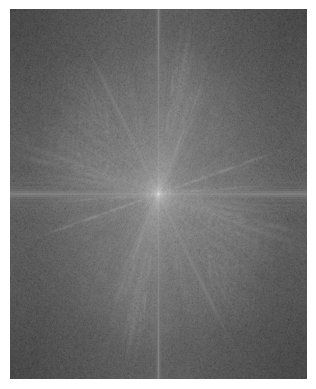

In [7]:
fft_original = fftshift(fft2(img))
log_magnitude_original = np.log1p(np.abs(fft_original))
plt.imshow(log_magnitude_original, cmap='gray')
plt.axis('off')
plt.savefig(plt_folder + 'log.png', dpi=300, bbox_inches='tight')
plt.show()

In [8]:
plt.rcParams['axes.titlesize'] = 12

Util func

In [ ]:
def draw_pics3(kernel, name):
    fig = plt.figure(figsize=(15, 18))

    plt.subplot(3, 3, 1)
    plt.axis('off')

    plt.subplot(3, 3, 2)
    plt.imshow(img, cmap='gray')
    plt.title('Исходное изображение')
    plt.axis('off')

    plt.subplot(3, 3, 3)
    plt.axis('off')

    for i, N in enumerate(N_values):
        conv_result = convolve2d(img, kernel(N), mode='same', boundary='symm')
        
        k_h, k_w = kernel.shape
        fft_size = (h + k_h - 1, w + k_w - 1)
        fft_img_padded = fft2(img, s=fft_size)  
        fft_kernel = fft2(kernel, s=fft_size)
        
        result_fft = ifft2(fft_img_padded * fft_kernel)
        start_i = (fft_size[0] - h) // 2
        start_j = (fft_size[1] - w) // 2
        fft_result = np.real(result_fft[start_i:start_i+h, start_j:start_j+w])
        
        plt.subplot(3, 3, i+4)
        plt.imshow(conv_result, cmap='gray')
        plt.title(f'Обычная свертка: N={N}')
        plt.axis('off')
        
        plt.subplot(3, 3, i+7)
        plt.imshow(fft_result, cmap='gray')
        plt.title(f'Фурье: N={N}')
        plt.axis('off')

    plt.tight_layout()
    plt.savefig(plt_folder + name + '_comp.png', dpi=200, bbox_inches='tight')
    plt.show()
    
    fig = plt.figure(figsize=(10, 18))

    plt.subplot(4, 3, 1)
    plt.axis('off')

    plt.subplot(4, 3, 2)
    plt.imshow(log_magnitude_original, cmap='gray')
    plt.title('Логарифм модуля фурье-образа исходного изображения')
    plt.axis('off')

    plt.subplot(4, 3, 3)
    plt.axis('off')

    for i, N in enumerate(N_values):
        conv_result = convolve2d(img, kernel, mode='same', boundary='symm')
        
        k_h, k_w = kernel.shape
        fft_size = (h + k_h - 1, w + k_w - 1)
        fft_img_padded = fft2(img, s=fft_size)
        fft_kernel = fft2(kernel, s=fft_size)
        result_fft = ifft2(fft_img_padded * fft_kernel)
        start_i = (fft_size[0] - h) // 2
        start_j = (fft_size[1] - w) // 2
        fft_result = np.real(result_fft[start_i:start_i+h, start_j:start_j+w])
        
        fft_kernel_shifted = fftshift(fft_kernel)
        log_magnitude_kernel = np.log1p(np.abs(fft_kernel_shifted))
        
        fft_conv_spectrum = fftshift(fft2(conv_result))
        log_magnitude_conv = np.log1p(np.abs(fft_conv_spectrum))
        
        fft_fft_spectrum = fftshift(fft2(fft_result))
        log_magnitude_fft = np.log1p(np.abs(fft_fft_spectrum))
        
        plt.subplot(4, 3, i*3 + 4)
        plt.imshow(log_magnitude_kernel, cmap='gray')
        plt.title(f'Логарифм модуля\nфурье-образа ядра: N={N}')
        plt.axis('off')
        
        plt.subplot(4, 3, i*3 + 5)
        plt.imshow(log_magnitude_conv, cmap='gray')
        plt.title(f'Лог. модуля фурье-обр. изобр.\nпосле обычной свертки: N={N}')
        plt.axis('off')
        
        plt.subplot(4, 3, i*3 + 6)
        plt.imshow(log_magnitude_fft, cmap='gray')
        plt.title(f'Лог. модуля фурье-обр. изобр.\nпосле фурье: N={N}')
        plt.axis('off')

    plt.tight_layout()
    plt.savefig(plt_folder + name + '_log.png', dpi=200, bbox_inches='tight')
    plt.show()

#### Размытие по Гауссу

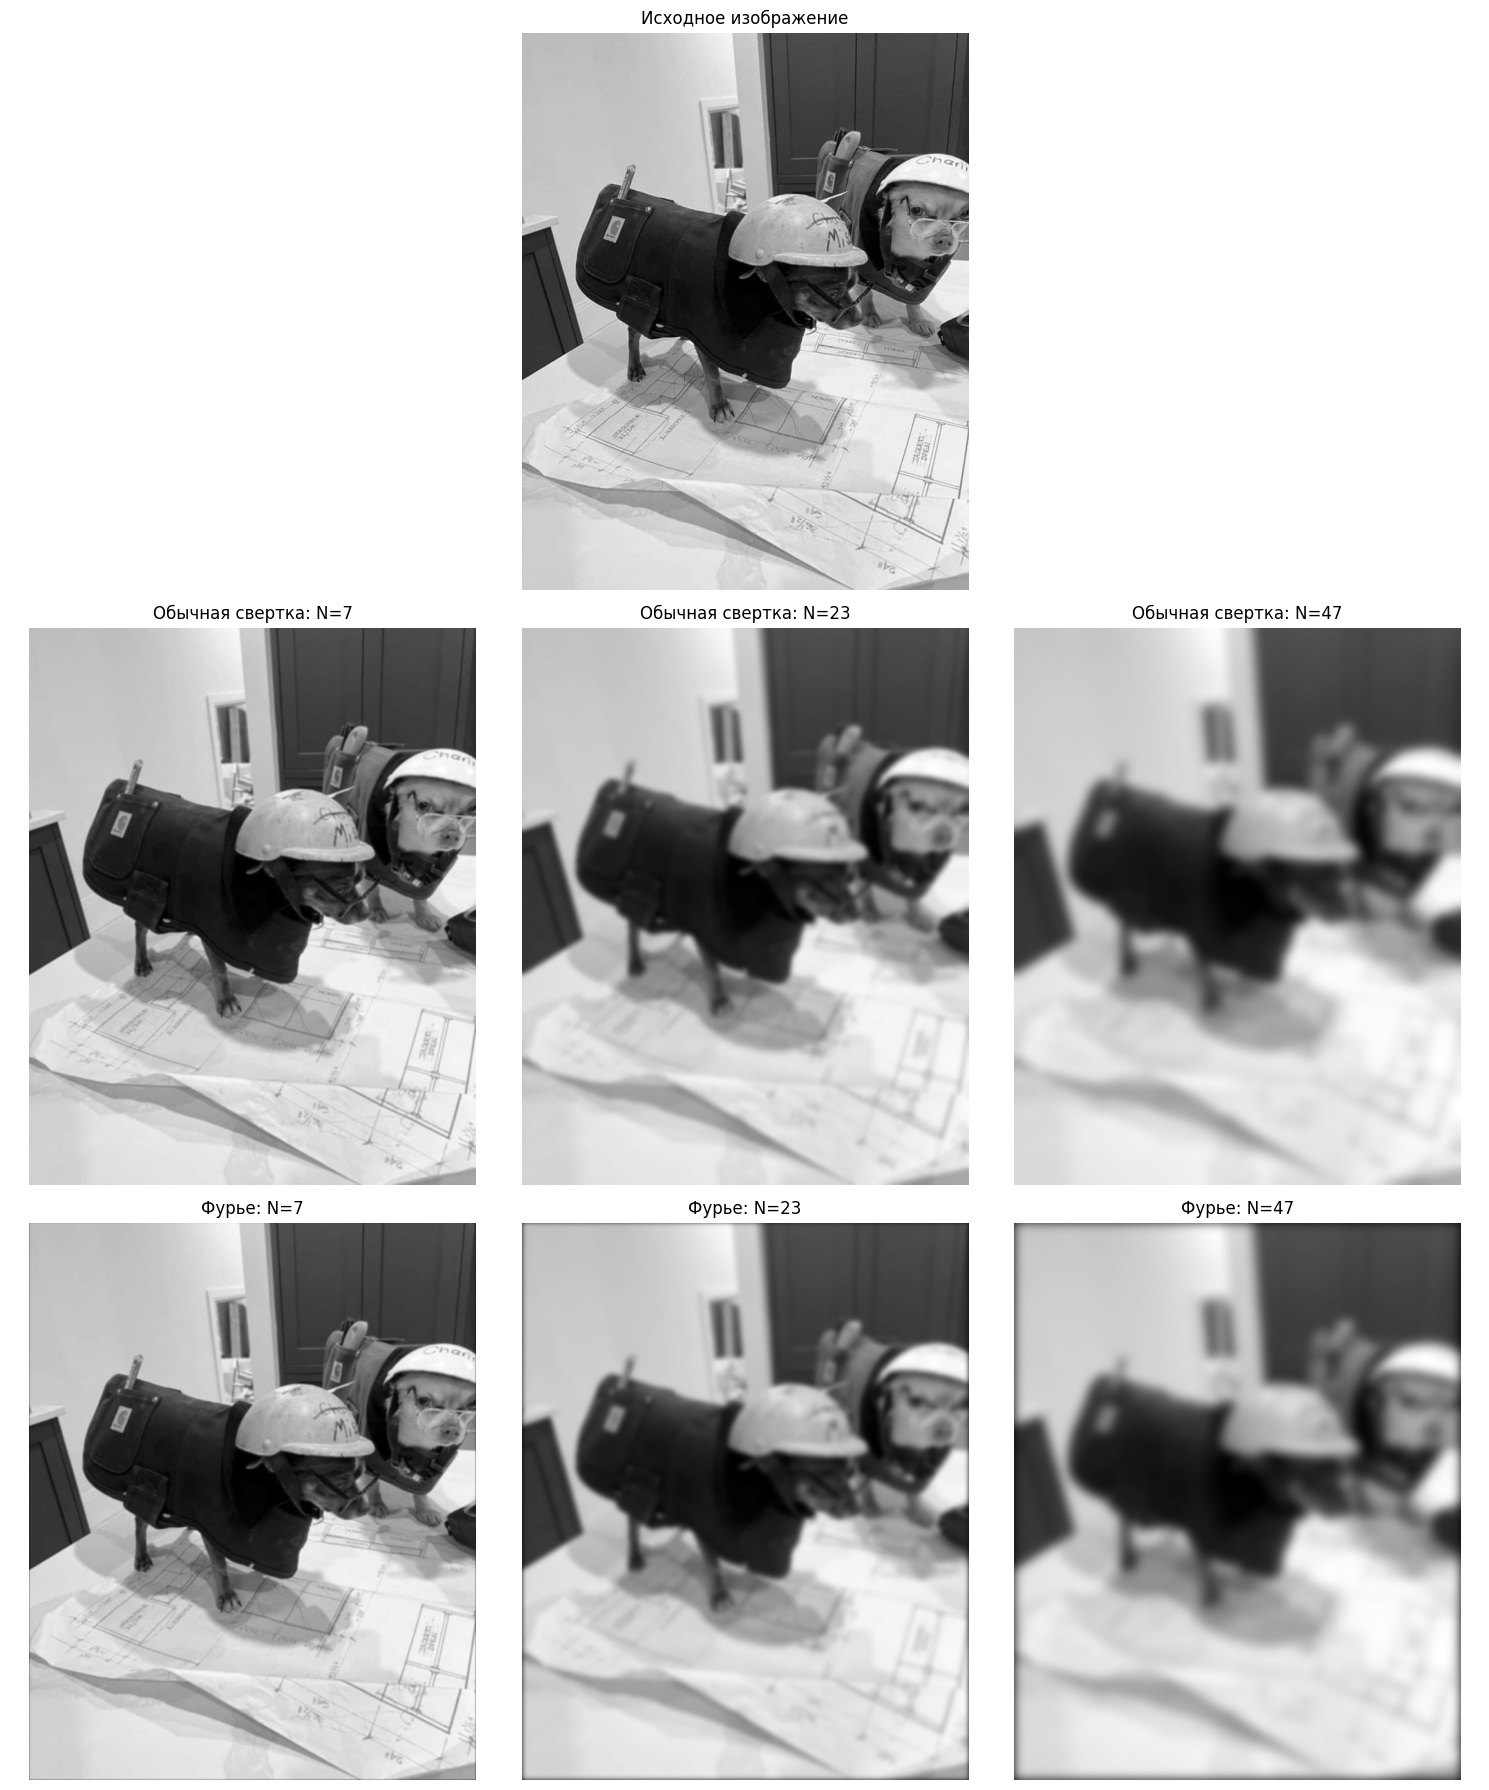

In [ ]:
draw_pics3(gaussian_kernel, "gaussian")

#### Блочное размытие

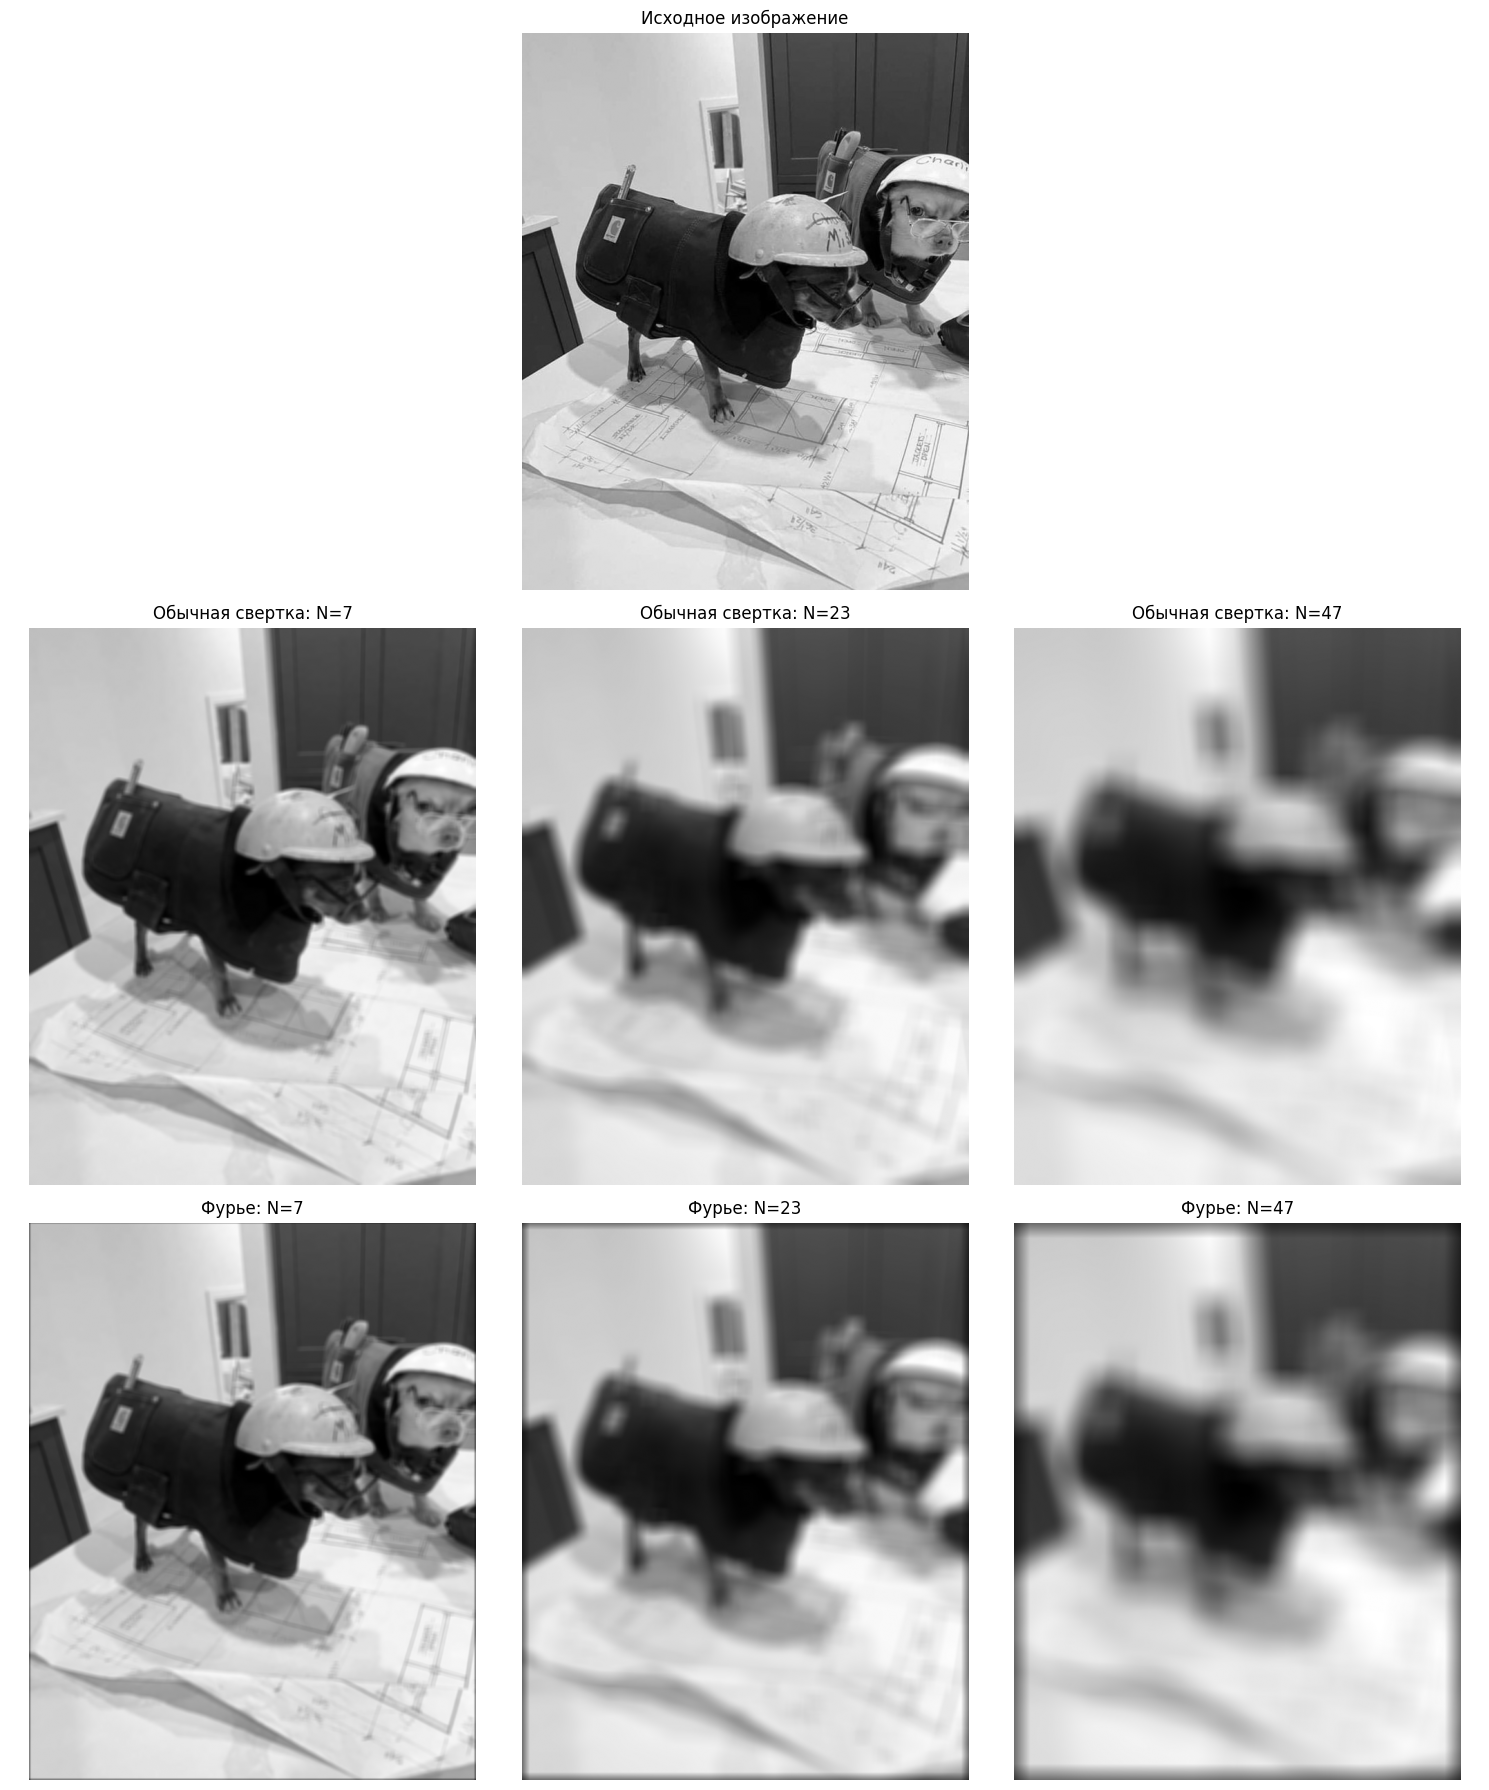

In [ ]:
draw_pics3(box_kernel, "gaussian")

Util func

In [29]:
def draw_pics(kernel, name):
    kernel = edge_kernel
    conv_result = convolve2d(img, kernel, mode='same', boundary='symm')

    k_h, k_w = kernel.shape
    fft_size = (h + k_h - 1, w + k_w - 1)
    fft_img_padded = fft2(img, s=fft_size)  
    fft_kernel = fft2(kernel, s=fft_size)

    result_fft = ifft2(fft_img_padded * fft_kernel)
    start_i = (fft_size[0] - h) // 2
    start_j = (fft_size[1] - w) // 2
    fft_result = np.real(result_fft[start_i:start_i+h, start_j:start_j+w])

    fig = plt.figure(figsize=(10, 8))

    plt.subplot(1, 3, 1)
    plt.imshow(img, cmap='gray')
    plt.title('Исходное изображение')
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(conv_result, cmap='gray')
    plt.title('Обычная свертка')
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(fft_result, cmap='gray')
    plt.title('Фурье')
    plt.axis('off')

    plt.tight_layout()
    plt.savefig(plt_folder + name + '_comp.png', dpi=200, bbox_inches='tight')
    plt.show()

    fft_kernel_shifted = fftshift(fft_kernel)
    log_magnitude_kernel = np.log1p(np.abs(fft_kernel_shifted))

    fft_conv_spectrum = fftshift(fft2(conv_result))
    log_magnitude_conv = np.log1p(np.abs(fft_conv_spectrum))

    fft_fft_spectrum = fftshift(fft2(fft_result))
    log_magnitude_fft = np.log1p(np.abs(fft_fft_spectrum))

    fig = plt.figure(figsize=(8, 10))

    plt.subplot(2, 2, 1)
    plt.imshow(log_magnitude_original, cmap='gray')
    plt.title('Логарифм модуля фурье-образа\nисходного изображения')
    plt.axis('off')

    plt.subplot(2, 2, 2)
    plt.imshow(log_magnitude_kernel, cmap='gray')
    plt.title('Логарифм модуля фурье-образа ядра')
    plt.axis('off')

    plt.subplot(2, 2, 3)
    plt.imshow(log_magnitude_conv, cmap='gray')
    plt.title('Логарифм модуля фурье-образа\nпосле обычной свертки')
    plt.axis('off')

    plt.subplot(2, 2, 4)
    plt.imshow(log_magnitude_fft, cmap='gray')
    plt.title('Логарифм модуля фурье-образа\nпосле фурье')
    plt.axis('off')

    plt.tight_layout()
    plt.savefig(plt_folder + name + '_log.png', dpi=200, bbox_inches='tight')
    plt.show()

#### Увеличение резкости

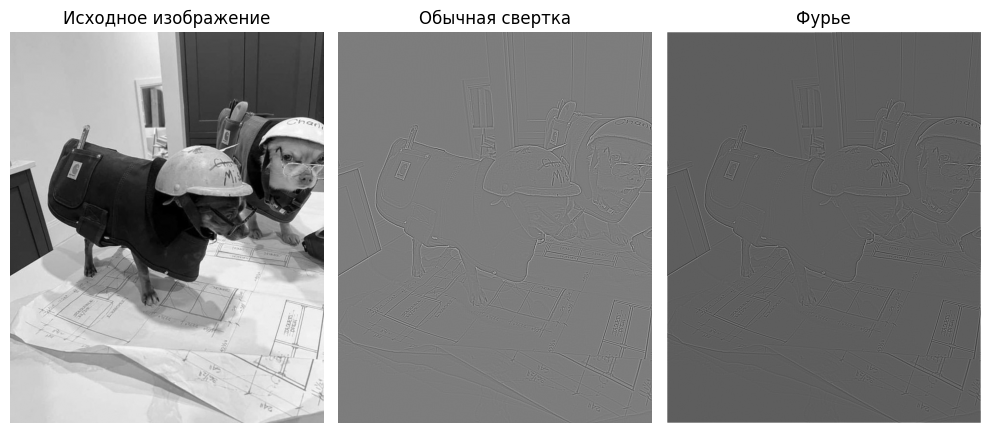

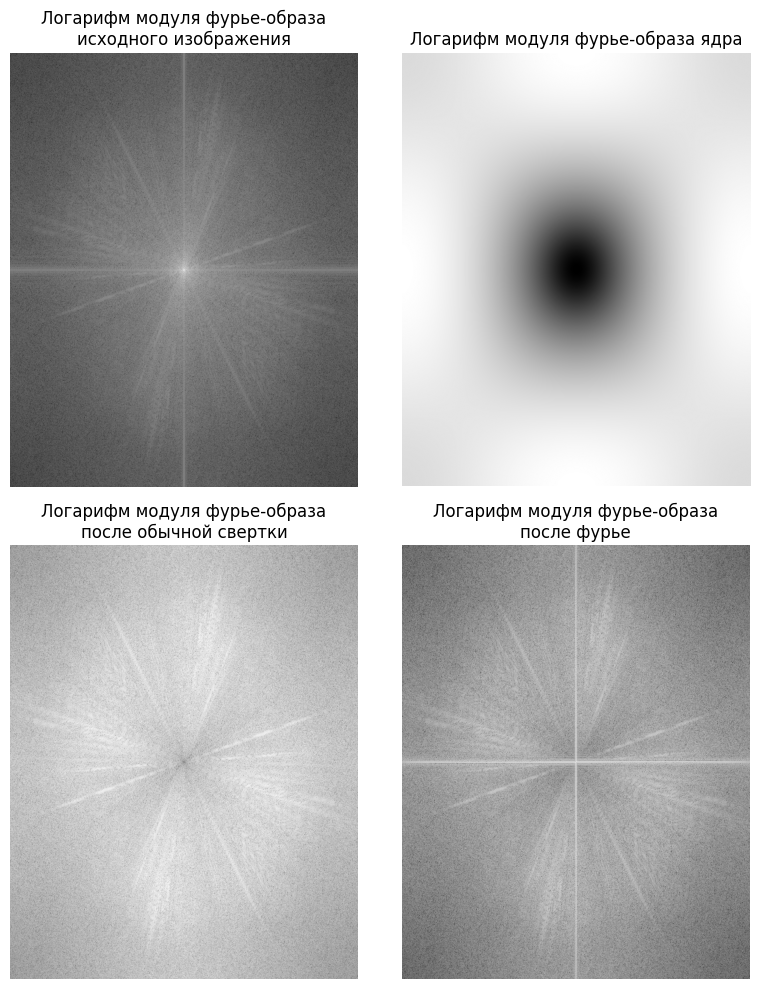

In [30]:
draw_pics(sharp_kernel, "sharp")

#### Выделение краёв

In [ ]:
draw_pics(edge_kernel, "edge")

#### Негатив

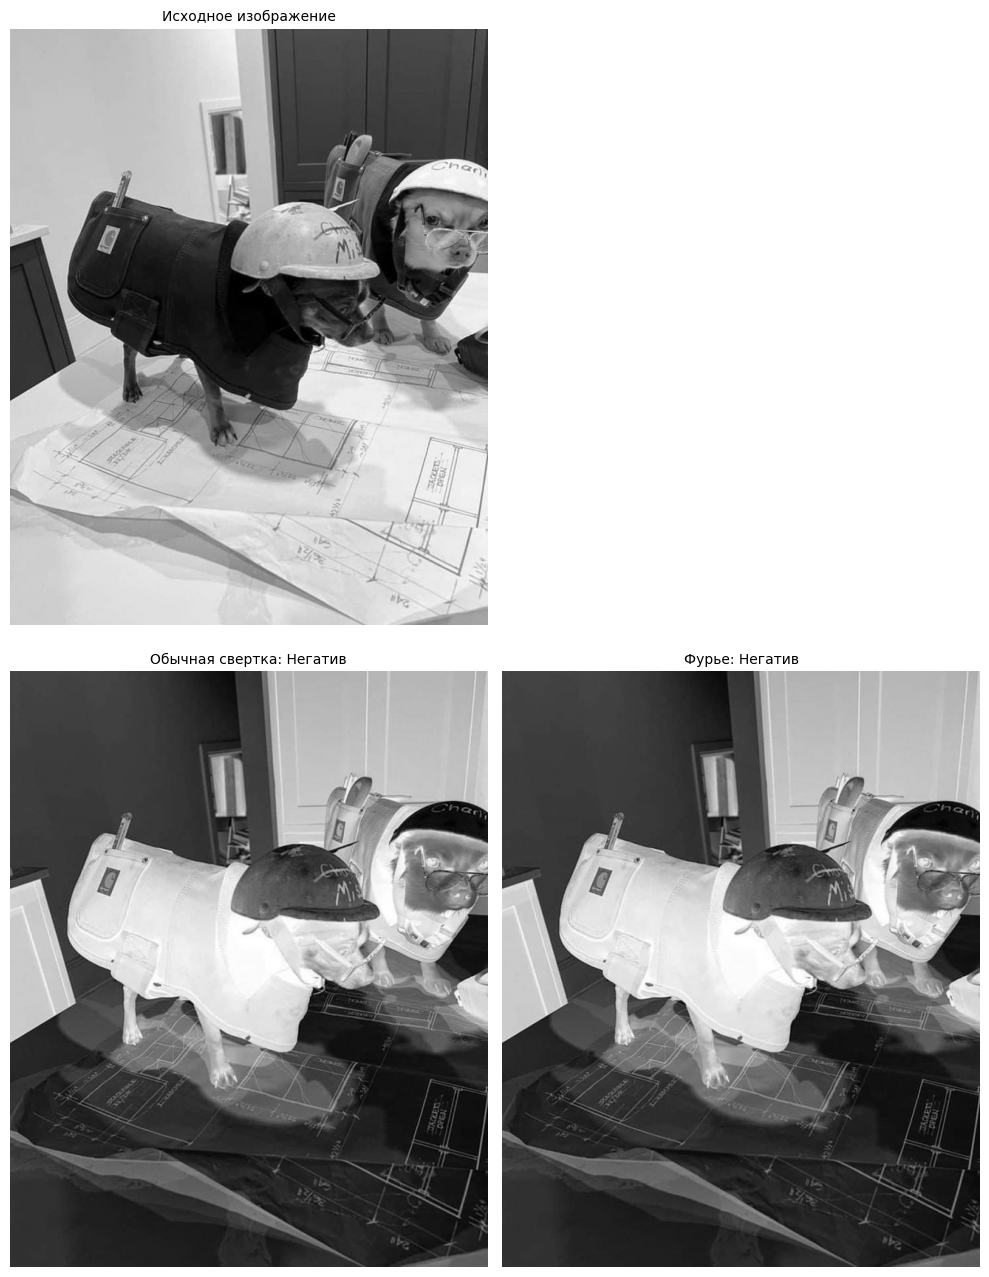

In [ ]:
draw_pics(negative_kernel, "neg")